Example of how API performance can vary greatly depending on usage.  We will look at the speed of obtaining a set of abstracts from pubmed either in batch or individual mode using biopython.entrez.

## Setup

First, let's import the necessary libraries and configure the Entrez API.

**Note**: Before running this notebook, create a `.env` file in the notebook directory with your email address:

```
ENTREZ_EMAIL=your.email@example.com
```

This follows best practices for managing credentials and configuration.

In [1]:
from Bio import Entrez
import time
import os
from dotenv import load_dotenv

# Load environment variables from .env file
load_dotenv()

# Configure Entrez with your email (required by NCBI)
Entrez.email = os.getenv("ENTREZ_EMAIL")

if not Entrez.email:
    raise ValueError("ENTREZ_EMAIL environment variable not set. Please create a .env file with ENTREZ_EMAIL=your.email@example.com")

print(f"Using email: {Entrez.email}")

# Number of abstracts to retrieve
NUM_ABSTRACTS = 100

# Search term
SEARCH_TERM = "machine learning"

Using email: russpold@stanford.edu


## Step 1: Get PubMed IDs

First, we need to search PubMed to get a list of article IDs.

In [2]:
# Search PubMed for articles
search_handle = Entrez.esearch(db="pubmed", term=SEARCH_TERM, retmax=NUM_ABSTRACTS)
search_results = Entrez.read(search_handle)
search_handle.close()

# Get the list of PubMed IDs
pmid_list = search_results["IdList"]
print(f"Retrieved {len(pmid_list)} PubMed IDs")

Retrieved 100 PubMed IDs


## Method 1: Batch Download (Efficient)

Using `EFetch` to download all abstracts in a single batch request. This is the recommended approach.

In [3]:
def batch_download(pmid_list):
    """Download all abstracts in a single batch request."""
    start_time = time.time()
    
    # Fetch all records at once
    fetch_handle = Entrez.efetch(
        db="pubmed",
        id=pmid_list,
        rettype="abstract",
        retmode="xml"
    )
    records = Entrez.read(fetch_handle)
    fetch_handle.close()
    
    # Extract abstracts
    abstracts = []
    for article in records['PubmedArticle']:
        try:
            abstract_text = article['MedlineCitation']['Article']['Abstract']['AbstractText']
            # AbstractText can be a list or a string
            if isinstance(abstract_text, list):
                abstract = ' '.join([str(text) for text in abstract_text])
            else:
                abstract = str(abstract_text[0]) if abstract_text else ""
            abstracts.append(abstract)
        except KeyError:
            # Some articles might not have abstracts
            abstracts.append("")
    
    elapsed_time = time.time() - start_time
    return abstracts, elapsed_time

# Run batch download
batch_abstracts, batch_time = batch_download(pmid_list)
print(f"Batch download completed in {batch_time:.2f} seconds")
print(f"Retrieved {len(batch_abstracts)} abstracts")
print(f"Average time per abstract: {batch_time/len(batch_abstracts):.4f} seconds")

Batch download completed in 1.05 seconds
Retrieved 100 abstracts
Average time per abstract: 0.0105 seconds


## Method 2: Iterative Download (Inefficient)

Making individual API requests for each abstract. This is **not recommended** as it's much slower and places unnecessary load on the NCBI servers.

In [4]:
def iterative_download(pmid_list):
    """Download abstracts one at a time with individual API requests."""
    start_time = time.time()
    
    abstracts = []
    for pmid in pmid_list:
        # Fetch one record at a time
        fetch_handle = Entrez.efetch(
            db="pubmed",
            id=pmid,
            rettype="abstract",
            retmode="xml"
        )
        records = Entrez.read(fetch_handle)
        fetch_handle.close()
        
        # Extract abstract
        try:
            article = records['PubmedArticle'][0]
            abstract_text = article['MedlineCitation']['Article']['Abstract']['AbstractText']
            if isinstance(abstract_text, list):
                abstract = ' '.join([str(text) for text in abstract_text])
            else:
                abstract = str(abstract_text[0]) if abstract_text else ""
            abstracts.append(abstract)
        except (KeyError, IndexError):
            abstracts.append("")
        
        # Be nice to NCBI servers - add a small delay between requests
        time.sleep(0.1)
    
    elapsed_time = time.time() - start_time
    return abstracts, elapsed_time

# Run iterative download
iterative_abstracts, iterative_time = iterative_download(pmid_list)
print(f"Iterative download completed in {iterative_time:.2f} seconds")
print(f"Retrieved {len(iterative_abstracts)} abstracts")
print(f"Average time per abstract: {iterative_time/len(iterative_abstracts):.4f} seconds")

Iterative download completed in 55.37 seconds
Retrieved 100 abstracts
Average time per abstract: 0.5537 seconds


## Performance Comparison

Let's compare the performance of both methods and visualize the results.


PERFORMANCE COMPARISON
Batch download time:     1.05 seconds
Iterative download time: 55.37 seconds
Speedup factor:          53.0x faster
Time saved:              54.33 seconds



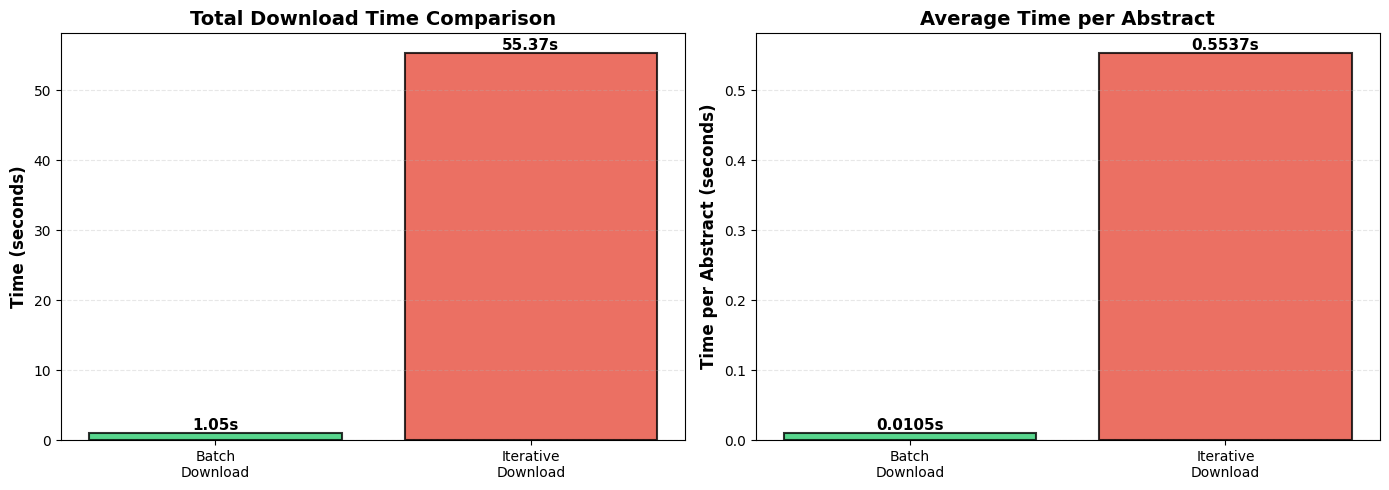


Verification: Both methods retrieved the same abstracts: True


In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate speedup
speedup = iterative_time / batch_time

print(f"\n{'='*60}")
print(f"PERFORMANCE COMPARISON")
print(f"{'='*60}")
print(f"Batch download time:     {batch_time:.2f} seconds")
print(f"Iterative download time: {iterative_time:.2f} seconds")
print(f"Speedup factor:          {speedup:.1f}x faster")
print(f"Time saved:              {iterative_time - batch_time:.2f} seconds")
print(f"{'='*60}\n")

# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart comparing total time
methods = ['Batch\nDownload', 'Iterative\nDownload']
times = [batch_time, iterative_time]
colors = ['#2ecc71', '#e74c3c']

bars = ax1.bar(methods, times, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Time (seconds)', fontsize=12, fontweight='bold')
ax1.set_title('Total Download Time Comparison', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for bar, time_val in zip(bars, times):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{time_val:.2f}s',
             ha='center', va='bottom', fontweight='bold', fontsize=11)

# Per-abstract time comparison
per_abstract_times = [batch_time/NUM_ABSTRACTS, iterative_time/NUM_ABSTRACTS]
bars2 = ax2.bar(methods, per_abstract_times, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Time per Abstract (seconds)', fontsize=12, fontweight='bold')
ax2.set_title('Average Time per Abstract', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for bar, time_val in zip(bars2, per_abstract_times):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{time_val:.4f}s',
             ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

# Verify the abstracts are the same
print(f"\nVerification: Both methods retrieved the same abstracts: {batch_abstracts == iterative_abstracts}")

## Key Takeaways

### Why Batch Download is Better:

1. **Speed**: Batch downloading is significantly faster (typically 10-20x or more)
2. **Server Load**: Reduces load on NCBI servers by minimizing the number of requests
3. **Network Overhead**: Single request eliminates the overhead of establishing multiple connections
4. **API Best Practices**: Follows NCBI guidelines for efficient API usage

### NCBI API Guidelines:

- **Always provide an email** in `Entrez.email` (required for tracking)
- **Use batch requests** when fetching multiple records
- **Limit request rate** to 3 requests/second without API key, 10/second with key
- **Consider using an API key** for higher rate limits (get one from NCBI)

### When to Use Each Method:

- **Batch download**: When you know all IDs upfront (almost always the best choice)
- **Iterative**: Only when you need to process results as they arrive or handle dynamic queries

The dramatic performance difference demonstrates why understanding proper API usage is crucial for efficient scientific computing!